✅ Loaded pre
✅ Loaded post
✅ Loaded nobn


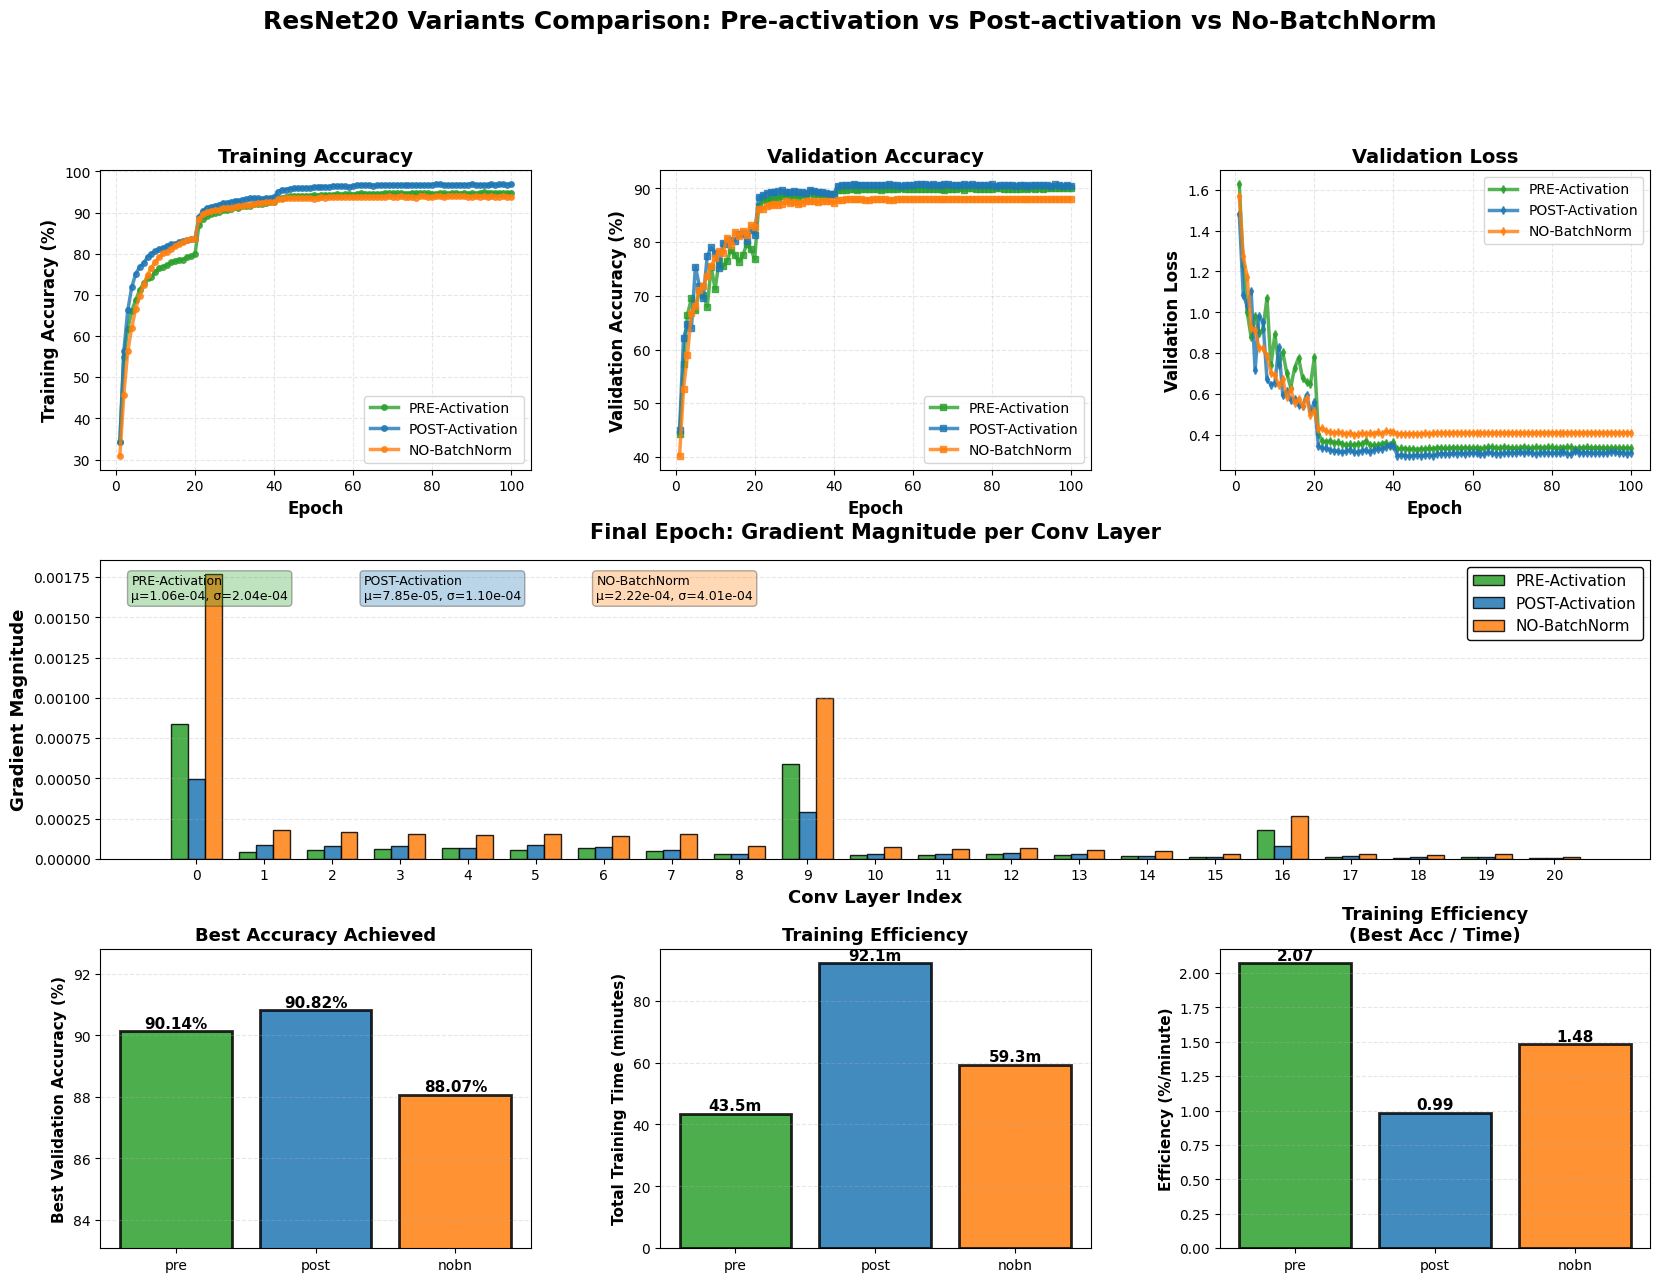


                                    SUMMARY STATISTICS                                    
VARIANT         BEST ACC     FINAL ACC    FINAL LOSS   TIME         EFFICIENCY     
PRE-Activation   90.14%      89.97%      0.3356      43.50min     2.07 %/min
POST-Activation  90.82%      90.50%      0.3136      92.11min     0.99 %/min
NO-BatchNorm     88.07%      87.98%      0.4113      59.34min     1.48 %/min

                           GRADIENT FLOW ANALYSIS (FINAL EPOCH)                           

PRE-Activation:
  Mean gradient:          1.0569e-04
  Std gradient:           2.0415e-04
  Min gradient (L20):    4.5107e-06
  Max gradient (L0):    8.3798e-04
  Gradient ratio:         185.77x
  Coefficient of var:     193.15%
  Early/Late layer ratio: 39.96x

POST-Activation:
  Mean gradient:          7.8543e-05
  Std gradient:           1.1005e-04
  Min gradient (L20):    7.7574e-06
  Max gradient (L0):    4.9528e-04
  Gradient ratio:         63.85x
  Coefficient of var:     140.11%
  Early/

In [9]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# ============================================================================
# LOAD ALL RESULTS
# ============================================================================
variants = ['pre', 'post', 'nobn']
variant_names = {
    'pre': 'PRE-Activation',
    'post': 'POST-Activation',
    'nobn': 'NO-BatchNorm'
}
colors = {
    'pre': '#2ca02c',   # Green
    'post': '#1f77b4',  # Blue
    'nobn': '#ff7f0e'   # Orange
}

results = {}
for v in variants:
    try:
        with open(f'results_{v}.pkl', 'rb') as f:
            results[v] = pickle.load(f)
        print(f"✅ Loaded {v}")
    except FileNotFoundError:
        print(f"⚠️  results_{v}.pkl not found - skipping")

if len(results) == 0:
    print("❌ No results found!")
    exit()

# ============================================================================
# CREATE COMPREHENSIVE FIGURE
# ============================================================================
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# ============================================================================
# ROW 1: ACCURACY AND LOSS CURVES
# ============================================================================

# Plot 1: Training Accuracy
ax1 = fig.add_subplot(gs[0, 0])
for v in variants:
    if v in results:
        epochs = range(1, len(results[v]['train_accs']) + 1)
        ax1.plot(epochs, np.array(results[v]['train_accs']) * 100,
                marker='o', label=variant_names[v], linewidth=2.5,
                color=colors[v], markersize=4, alpha=0.8)

ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Training Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Training Accuracy', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10, loc='lower right')
ax1.grid(True, alpha=0.3, linestyle='--')

# Plot 2: Validation Accuracy
ax2 = fig.add_subplot(gs[0, 1])
for v in variants:
    if v in results:
        epochs = range(1, len(results[v]['val_accs']) + 1)
        ax2.plot(epochs, np.array(results[v]['val_accs']) * 100,
                marker='s', label=variant_names[v], linewidth=2.5,
                color=colors[v], markersize=4, alpha=0.8)

ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Validation Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10, loc='lower right')
ax2.grid(True, alpha=0.3, linestyle='--')

# Plot 3: Validation Loss
ax3 = fig.add_subplot(gs[0, 2])
for v in variants:
    if v in results:
        epochs = range(1, len(results[v]['val_losses']) + 1)
        ax3.plot(epochs, results[v]['val_losses'],
                marker='d', label=variant_names[v], linewidth=2.5,
                color=colors[v], markersize=4, alpha=0.8)

ax3.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax3.set_ylabel('Validation Loss', fontsize=12, fontweight='bold')
ax3.set_title('Validation Loss', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10, loc='upper right')
ax3.grid(True, alpha=0.3, linestyle='--')

# ============================================================================
# ROW 2: GRADIENT MAGNITUDE BAR CHARTS
# ============================================================================

# Extract final gradients
final_gradients = {}
for v in variants:
    if v in results and results[v]['gradient_history'] is not None:
        final_gradients[v] = results[v]['gradient_history'][-1, :]

if len(final_gradients) > 0:
    num_layers = len(list(final_gradients.values())[0])
    x = np.arange(num_layers)
    width = 0.25

    # Plot 4: Gradient Magnitude Comparison (Side-by-side bars)
    ax4 = fig.add_subplot(gs[1, :])  # Span all columns

    for i, v in enumerate(variants):
        if v in final_gradients:
            offset = (i - 1) * width
            bars = ax4.bar(x + offset, final_gradients[v], width,
                          label=variant_names[v], alpha=0.85,
                          color=colors[v], edgecolor='black', linewidth=1)

    ax4.set_xlabel('Conv Layer Index', fontsize=13, fontweight='bold')
    ax4.set_ylabel('Gradient Magnitude', fontsize=13, fontweight='bold')
    ax4.set_title('Final Epoch: Gradient Magnitude per Conv Layer',
                  fontsize=15, fontweight='bold', pad=15)
    ax4.legend(fontsize=11, loc='upper right', framealpha=0.95, edgecolor='black')
    ax4.grid(True, alpha=0.3, axis='y', linestyle='--')
    ax4.set_xticks(x)
    ax4.set_xticklabels([f'{i}' for i in x])

    # Add text with layer statistics
    for i, v in enumerate(variants):
        if v in final_gradients:
            mean_grad = final_gradients[v].mean()
            std_grad = final_gradients[v].std()
            ax4.text(0.02 + i*0.15, 0.95,
                    f'{variant_names[v]}\nμ={mean_grad:.2e}, σ={std_grad:.2e}',
                    transform=ax4.transAxes, fontsize=9,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor=colors[v],
                             alpha=0.3, edgecolor='black'))

# ============================================================================
# ROW 3: SUMMARY STATISTICS
# ============================================================================

# Plot 5: Best Accuracy Comparison (Bar chart)
ax5 = fig.add_subplot(gs[2, 0])
best_accs = {}
for v in variants:
    if v in results:
        best_accs[v] = max(results[v]['val_accs']) * 100

if best_accs:
    bars = ax5.bar(best_accs.keys(), best_accs.values(),
                   color=[colors[v] for v in best_accs.keys()],
                   alpha=0.85, edgecolor='black', linewidth=2)
    ax5.set_ylabel('Best Validation Accuracy (%)', fontsize=11, fontweight='bold')
    ax5.set_title('Best Accuracy Achieved', fontsize=13, fontweight='bold')
    ax5.set_ylim([min(best_accs.values()) - 5, max(best_accs.values()) + 2])
    ax5.grid(True, alpha=0.3, axis='y', linestyle='--')

    # Add value labels on bars
    for bar, (v, acc) in zip(bars, best_accs.items()):
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.2f}%',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 6: Training Time Comparison
ax6 = fig.add_subplot(gs[2, 1])
training_times = {}
for v in variants:
    if v in results:
        training_times[v] = sum(results[v]['epoch_times']) / 60  # Convert to minutes

if training_times:
    bars = ax6.bar(training_times.keys(), training_times.values(),
                   color=[colors[v] for v in training_times.keys()],
                   alpha=0.85, edgecolor='black', linewidth=2)
    ax6.set_ylabel('Total Training Time (minutes)', fontsize=11, fontweight='bold')
    ax6.set_title('Training Efficiency', fontsize=13, fontweight='bold')
    ax6.grid(True, alpha=0.3, axis='y', linestyle='--')

    # Add value labels
    for bar, (v, time) in zip(bars, training_times.items()):
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                f'{time:.1f}m',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 7: Efficiency Metric (Accuracy per minute)
ax7 = fig.add_subplot(gs[2, 2])
efficiency = {}
for v in variants:
    if v in results and v in best_accs and v in training_times:
        efficiency[v] = best_accs[v] / training_times[v]  # % per minute

if efficiency:
    bars = ax7.bar(efficiency.keys(), efficiency.values(),
                   color=[colors[v] for v in efficiency.keys()],
                   alpha=0.85, edgecolor='black', linewidth=2)
    ax7.set_ylabel('Efficiency (%/minute)', fontsize=11, fontweight='bold')
    ax7.set_title('Training Efficiency\n(Best Acc / Time)', fontsize=13, fontweight='bold')
    ax7.grid(True, alpha=0.3, axis='y', linestyle='--')

    # Add value labels
    for bar, (v, eff) in zip(bars, efficiency.items()):
        height = bar.get_height()
        ax7.text(bar.get_x() + bar.get_width()/2., height,
                f'{eff:.2f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add overall title
fig.suptitle('ResNet20 Variants Comparison: Pre-activation vs Post-activation vs No-BatchNorm',
            fontsize=18, fontweight='bold', y=0.995)

plt.savefig('complete_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

# ============================================================================
# PRINT SUMMARY TABLE
# ============================================================================
print("\n" + "="*90)
print(f"{'SUMMARY STATISTICS':^90}")
print("="*90)
print(f"{'VARIANT':<15} {'BEST ACC':<12} {'FINAL ACC':<12} {'FINAL LOSS':<12} "
      f"{'TIME':<12} {'EFFICIENCY':<15}")
print("="*90)

for v in variants:
    if v in results:
        best_acc = max(results[v]['val_accs']) * 100
        final_acc = results[v]['val_accs'][-1] * 100
        final_loss = results[v]['val_losses'][-1]
        total_time = sum(results[v]['epoch_times']) / 60
        efficiency = best_acc / total_time

        print(f"{variant_names[v]:<15} {best_acc:>6.2f}%     {final_acc:>6.2f}%     "
              f"{final_loss:>7.4f}     {total_time:>6.2f}min   {efficiency:>6.2f} %/min")

print("="*90)

# Gradient statistics
if len(final_gradients) > 0:
    print("\n" + "="*90)
    print(f"{'GRADIENT FLOW ANALYSIS (FINAL EPOCH)':^90}")
    print("="*90)

    for v in variants:
        if v in final_gradients:
            grads = final_gradients[v]
            print(f"\n{variant_names[v]}:")
            print(f"  Mean gradient:          {grads.mean():.4e}")
            print(f"  Std gradient:           {grads.std():.4e}")
            print(f"  Min gradient (L{grads.argmin()}):    {grads.min():.4e}")
            print(f"  Max gradient (L{grads.argmax()}):    {grads.max():.4e}")
            print(f"  Gradient ratio:         {grads.max()/grads.min():.2f}x")
            print(f"  Coefficient of var:     {(grads.std()/grads.mean())*100:.2f}%")

            # Check for vanishing gradients
            early_layers = grads[:3].mean()
            late_layers = grads[-3:].mean()
            balance = early_layers / late_layers if late_layers > 0 else float('inf')
            print(f"  Early/Late layer ratio: {balance:.2f}x")

print("\n" + "="*90)

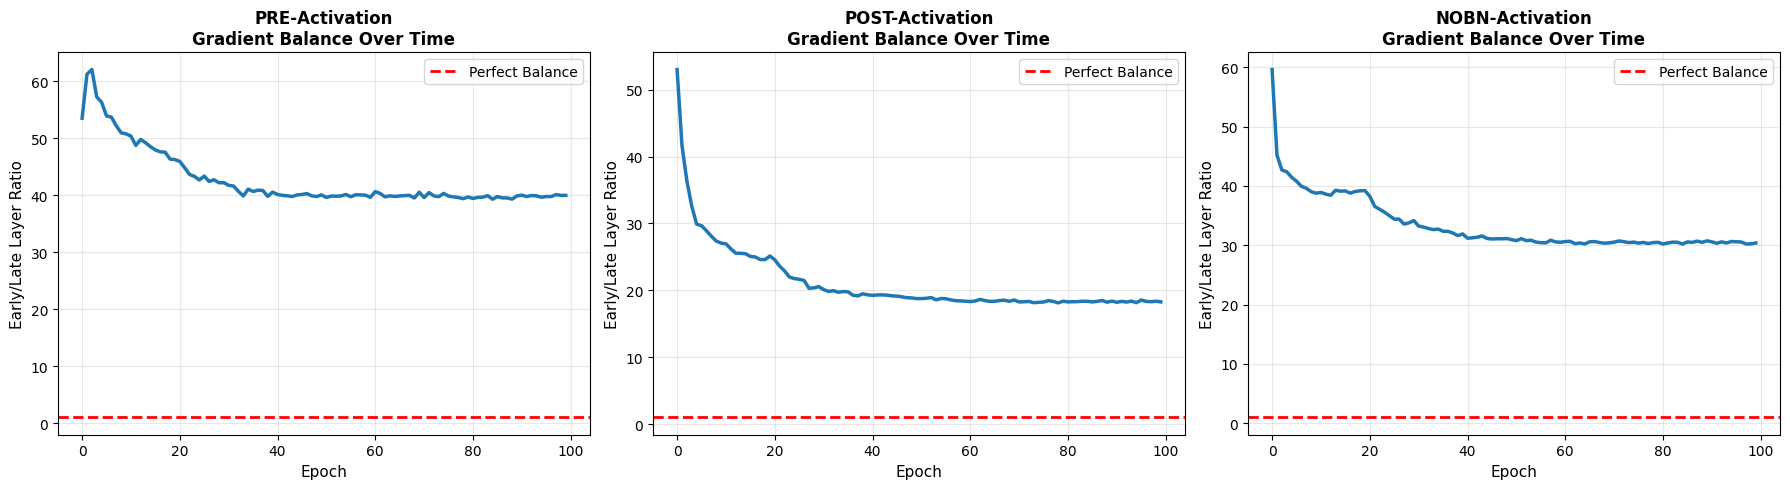

In [10]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, variant in enumerate(['pre', 'post', 'nobn']):
    grad_hist = results[variant]['gradient_history']

    # Calculate early/late ratio over time
    early_late_ratios = []
    for epoch in range(len(grad_hist)):
        early = grad_hist[epoch, :3].mean()
        late = grad_hist[epoch, -3:].mean()
        early_late_ratios.append(early / late if late > 0 else 0)

    axes[idx].plot(early_late_ratios, linewidth=2.5)
    axes[idx].set_title(f'{variant.upper()}-Activation\nGradient Balance Over Time',
                       fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Epoch', fontsize=11)
    axes[idx].set_ylabel('Early/Late Layer Ratio', fontsize=11)
    axes[idx].axhline(y=1.0, color='red', linestyle='--', linewidth=2,
                     label='Perfect Balance')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()

plt.tight_layout()
plt.savefig('gradient_balance_evolution.png', dpi=150)
plt.show()